[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Estudiantes:** López Granados Karito Dali Yoselyn - Gomez Muñoz David Pedro  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [ ]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

In [ ]:
URL = 'https://raw.githubusercontent.com/reddyprasade/Machine-Learning/master/Heart-Disease-UCI/heart.csv'

# Intentamos cargar desde la URL; si falla, usamos la copia local de Kaggle
try:
    df = pd.read_csv(URL)
    print(f'Dataset cargado desde URL — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde URL: {e}')
    print('Intentando cargar desde OpenML como alternativa...')
    # Alternativa: descarga desde el repo de Kaggle vía sklearn
    from sklearn.datasets import fetch_openml
    import scipy.sparse
    try:
        # First, fetch the full bunch to get feature names (return_X_y=False)
        full_bunch = fetch_openml(data_id=1574, as_frame=False, return_X_y=False)
        feature_names = full_bunch.feature_names

        # Then, explicitly fetch X (features) and y (target) as arrays (return_X_y=True)
        X_openml, y_openml = fetch_openml(data_id=1574, as_frame=False, return_X_y=True)

        # Check if X is a sparse matrix and convert to dense if necessary
        if scipy.sparse.issparse(X_openml):
            X_openml = X_openml.toarray()

        # Create a DataFrame from the data and target arrays
        df = pd.DataFrame(data=X_openml, columns=feature_names)
        df['target'] = y_openml

        # Ensure target is numeric, as OpenML often returns it as object type
        df['target'] = pd.to_numeric(df['target'])

        print(f'Dataset cargado desde OpenML — {df.shape[0]} registros, {df.shape[1]} columnas')
    except Exception as openml_e:
        print(f'Error al cargar desde OpenML: {openml_e}')
        print('No se pudo cargar el dataset desde ninguna fuente.')
        raise # Re-raise the exception if both methods fail

df.head()

Error al cargar desde URL: HTTP Error 404: Not Found
Intentando cargar desde OpenML como alternativa...
Dataset cargado desde OpenML — 270 registros, 14 columnas


,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
0,0.708333,1.0,1.000000,-0.320755,-0.105023,-1.0,1.0,-0.419847,-1.0,-0.225806,0.0,1.000000,-1.0,1.0
1,0.583333,-1.0,0.333333,-0.603774,1.000000,-1.0,1.0,0.358779,-1.0,-0.483871,0.0,-1.000000,1.0,-1.0
2,0.166667,1.0,-0.333333,-0.433962,-0.383562,-1.0,-1.0,0.068702,-1.0,-0.903226,-1.0,-1.000000,1.0,1.0
3,0.458333,1.0,1.000000,-0.358491,-0.374429,-1.0,-1.0,-0.480916,1.0,-0.935484,0.0,-0.333333,1.0,-1.0
4,0.875000,-1.0,-0.333333,-0.509434,-0.347032,-1.0,1.0,-0.236641,1.0,-0.935484,-1.0,-0.333333,-1.0,-1.0


---
## 3. Etapa 2 — Exploración y preparación de datos

In [ ]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   att_1   270 non-null    float64
 1   att_2   270 non-null    float64
 2   att_3   270 non-null    float64
 3   att_4   270 non-null    float64
 4   att_5   270 non-null    float64
 5   att_6   270 non-null    float64
 6   att_7   270 non-null    float64
 7   att_8   270 non-null    float64
 8   att_9   270 non-null    float64
 9   att_10  270 non-null    float64
 10  att_11  270 non-null    float64
 11  att_12  270 non-null    float64
 12  att_13  270 non-null    float64
 13  target  270 non-null    float64
dtypes: float64(14)
memory usage: 29.7 KB




,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,0.06,0.36,0.45,-0.30,-0.44,-0.70,0.02,0.20,-0.34,-0.66,-0.41,-0.55,-0.15,-0.11
std,0.38,0.94,0.63,0.34,0.24,0.71,1.00,0.35,0.94,0.37,0.61,0.63,0.97,1.00
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,-0.21,-1.00,0.33,-0.51,-0.60,-1.00,-1.00,-0.05,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
50%,0.08,1.00,0.33,-0.32,-0.46,-1.00,1.00,0.26,-1.00,-0.74,0.00,-1.00,-1.00,-1.00
75%,0.33,1.00,1.00,-0.13,-0.30,-1.00,1.00,0.45,1.00,-0.48,0.00,-0.33,1.00,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [ ]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
att_1     0
att_2     0
att_3     0
att_4     0
att_5     0
att_6     0
att_7     0
att_8     0
att_9     0
att_10    0
att_11    0
att_12    0
att_13    0
target    0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 270


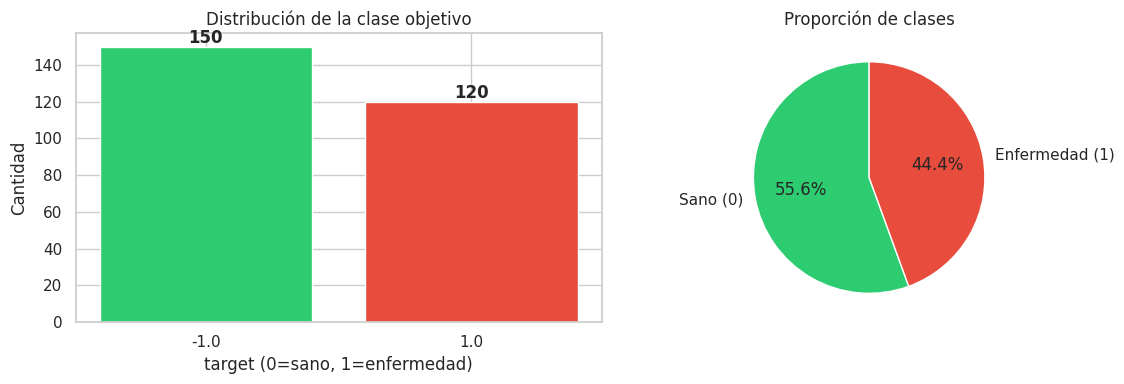

In [ ]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (0=sano, 1=enfermedad)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['Sano (0)', 'Enfermedad (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

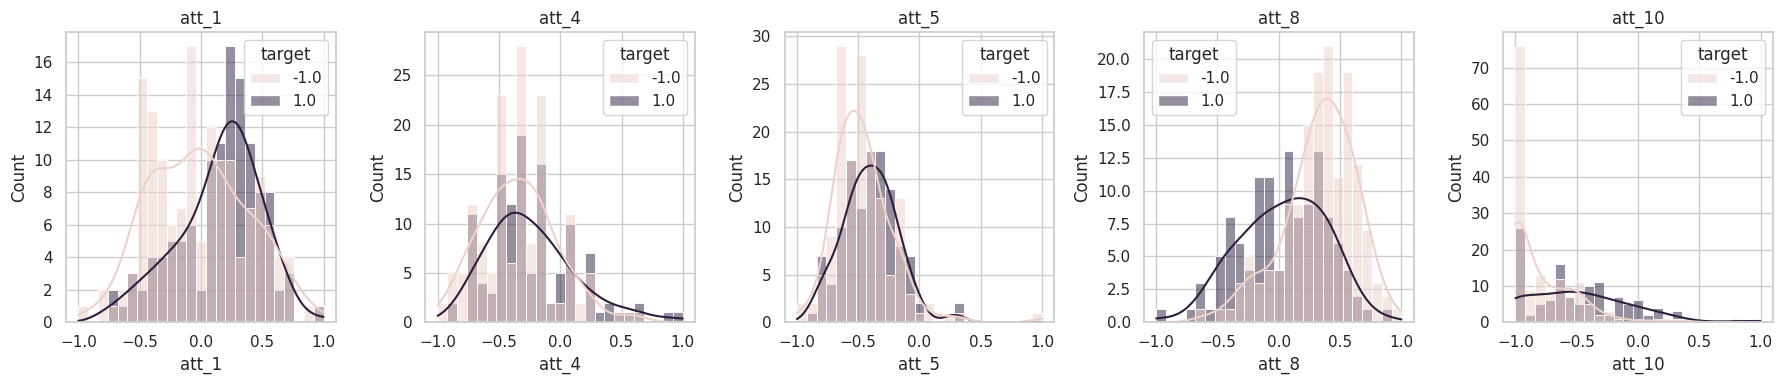

In [ ]:
# 3.4  Distribución de variables numéricas clave
# Mapeo de nombres originales a nombres genéricos de OpenML
# 'age' -> 'att_1'
# 'trestbps' -> 'att_4'
# 'chol' -> 'att_5'
# 'thalach' -> 'att_8'
# 'oldpeak' -> 'att_10'
num_cols = ['att_1', 'att_4', 'att_5', 'att_8', 'att_10']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

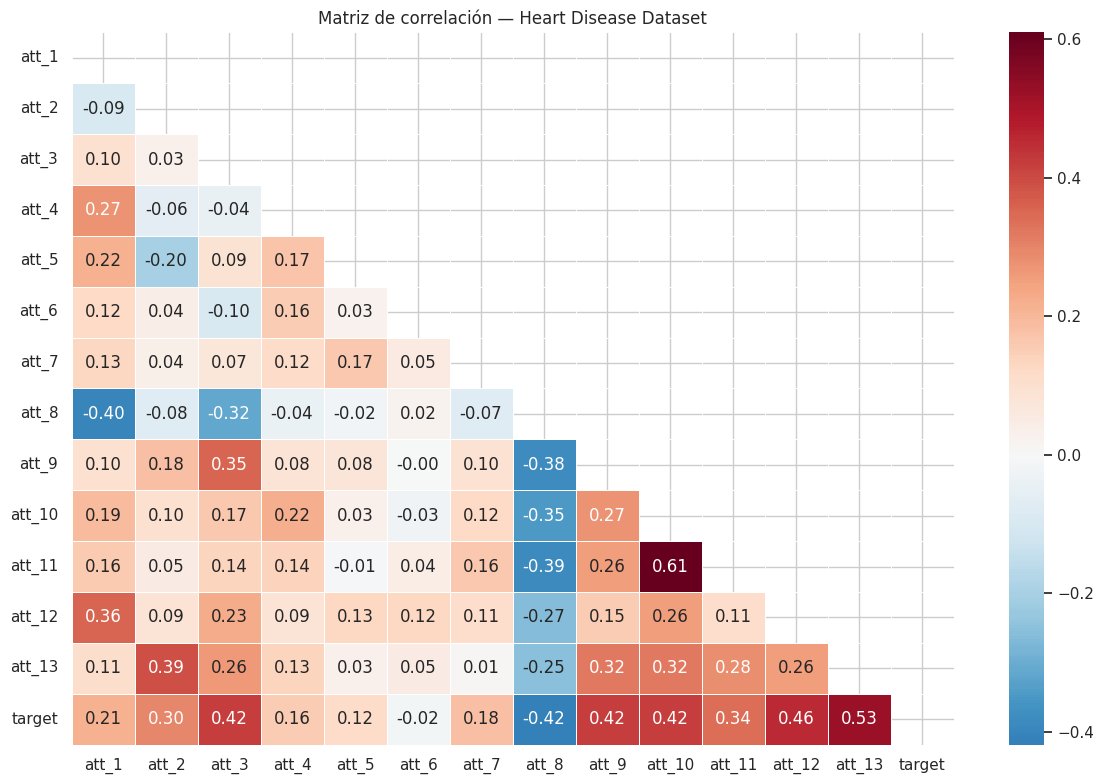

In [ ]:
# 3.5  Matriz de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Heart Disease Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [ ]:
# 4.1  Separación de features y target
X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (270, 13)
Target:   (270,)


In [ ]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 216 muestras
Test:  54 muestras

Proporción target en train:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64

Proporción target en test:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [ ]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8288 ± 0.0682
DecisionTree               Accuracy CV: 0.7637 ± 0.0350
RandomForest               Accuracy CV: 0.8148 ± 0.0390


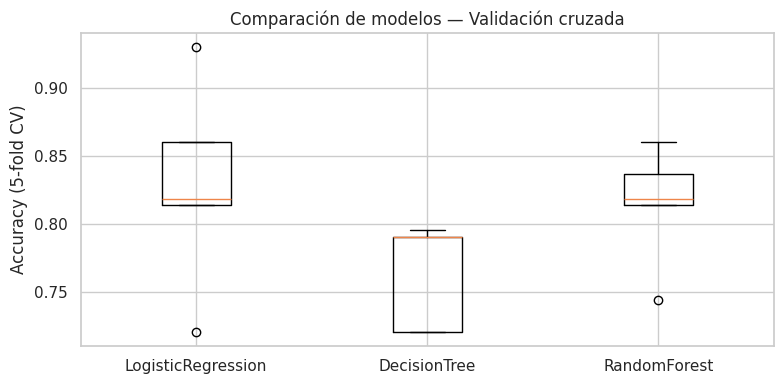

In [ ]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [ ]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Enfermedad']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.8519

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sano       0.92      0.80      0.86        30
  Enfermedad       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



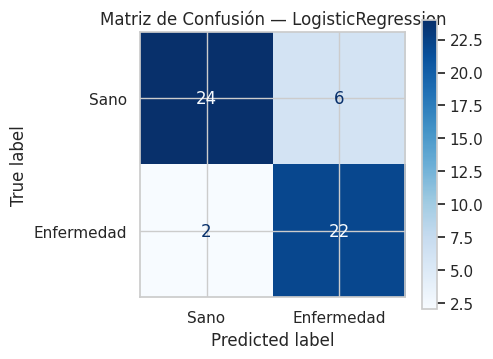

In [ ]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sano', 'Enfermedad'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

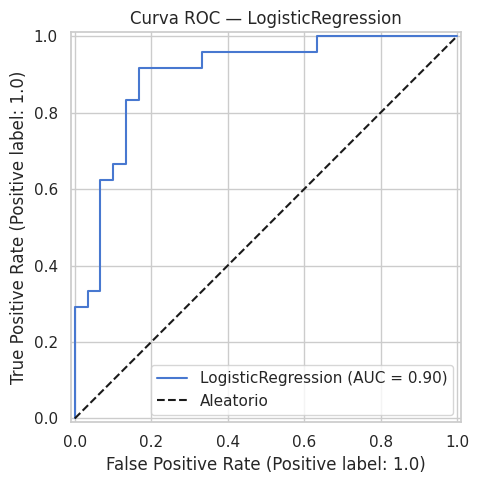

In [ ]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [ ]:
# 7.1  Guardar el modelo
MODEL_PATH = 'heart_disease_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: heart_disease_model.joblib


In [ ]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [ ]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_heart_disease(patient_data: dict) -> dict:
    """
    Recibe un diccionario con los features del paciente
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    # Mapeo de nombres originales a nombres genéricos de OpenML
    feature_name_map = {
        'age': 'att_1',
        'sex': 'att_2',
        'cp': 'att_3',
        'trestbps': 'att_4',
        'chol': 'att_5',
        'fbs': 'att_6',
        'restecg': 'att_7',
        'thalach': 'att_8',
        'exang': 'att_9',
        'oldpeak': 'att_10',
        'slope': 'att_11',
        'ca': 'att_12',
        'thal': 'att_13'
    }

    # Renombrar las claves en patient_data y asegurar el orden correcto de las columnas
    # 'feature_names' es una variable global del kernel que contiene el orden correcto de las columnas
    # (e.g., ['att_1', 'att_2', ..., 'att_13'])
    try:
        renamed_patient_data_ordered = {feature_name_map[k]: patient_data[k] for k in feature_name_map.keys()}
        ordered_values = [renamed_patient_data_ordered[name] for name in feature_names]
        input_df = pd.DataFrame([ordered_values], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Missing or incorrect feature name in patient_data: {e}. Expected descriptive names from the mapping.")

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    # Ajustar etiquetas de predicción según las clases del modelo (-1.0 y 1.0)
    prediction_label = 'Enfermedad cardíaca' if pred == 1.0 else 'Sano'

    # Asumiendo que proba[0] es para la clase -1.0 (Sano) y proba[1] para 1.0 (Enfermedad)
    return {
        'prediccion': prediction_label,
        'probabilidad_enfermedad': round(float(proba[1]), 4),
        'probabilidad_sano': round(float(proba[0]), 4)
    }

# Ejemplo de uso con un paciente ficticio
paciente_ejemplo = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140,
    'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150,
    'exang': 0, 'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}

resultado = predict_heart_disease(paciente_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Enfermedad cardíaca
  probabilidad_enfermedad: 1.0
  probabilidad_sano: 0.0


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
### ✅ Resolución — Ejercicio 1: Experimentación con hiperparámetros

Usamos `RandomizedSearchCV` (más eficiente que `GridSearchCV` cuando hay muchas combinaciones posibles) para buscar la mejor configuración del `RandomForestClassifier`, y comparamos el accuracy en test antes y después del tuning.

In [ ]:
# 9.1.1  Modelo RandomForest ANTES del tuning (hiperparámetros fijos, igual que en la sección 5)

rf_pipeline_base = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
])
rf_pipeline_base.fit(X_train, y_train)
acc_rf_before = rf_pipeline_base.score(X_test, y_test)

print(f'Accuracy RandomForest ANTES del tuning: {acc_rf_before:.4f}')

Accuracy RandomForest ANTES del tuning: 0.8333


In [ ]:
# 9.1.2  Definición del espacio de búsqueda de hiperparámetros
parametros_busqueda = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': [3, 5, 7, 9, 11, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None]
}

In [ ]:
# 9.1.3 Importamos GridSearchCV
from sklearn.model_selection import GridSearchCV

rf_grid = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=parametros_busqueda,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

In [ ]:
# 9.1.4 Resultados de GridSearchCV
print("Mejores hiperparámetros encontrados por GridSearchCV:")
print(grid_search.best_params_)

print(f"Mejor accuracy promedio en validación cruzada: "
      f"{grid_search.best_score_:.4f}")

Mejores hiperparámetros encontrados por GridSearchCV:
{'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
Mejor accuracy promedio en validación cruzada: 0.8473


In [ ]:
# 9.1.5 Accuracy de GridSearchCV
rf_grid_tuned = grid_search.best_estimator_

acc_grid = rf_grid_tuned.score(X_test, y_test)

print(f"Accuracy GridSearchCV en el conjunto de prueba: {acc_grid:.4f}")


Accuracy GridSearchCV en el conjunto de prueba: 0.8519


In [ ]:
# 9.1.6 Importamos RandomizeSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf_random = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=parametros_busqueda,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('clf',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'clf__max_depth': [3, 5, 7, 9, 11,
                                                           None],
                                        'clf__max_features': ['sqrt', 'log2',
                                                              None],
                                        'clf__min_samples_leaf': [1, 2, 4],
                                        'clf__min_samples_split': [2, 5, 10],
                                        'clf__n_estimators': [100, 200, 300,
                                                              400, 500]},
                   random_state=42, scoring='accuracy')

In [ ]:
# 9.1.7 Resultados de RandomizedSearchCV
print("Mejores hiperparámetros encontrados por RandomizedSearchCV:")
print(random_search.best_params_)

print(f"Mejor accuracy promedio en validación cruzada: "
      f"{random_search.best_score_:.4f}")

Mejores hiperparámetros encontrados por RandomizedSearchCV:
{'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': 3}
Mejor accuracy promedio en validación cruzada: 0.8426


In [ ]:
# 9.1.8 Accuracy de RandomizedSearchCV
rf_random_tuned = random_search.best_estimator_

acc_random = rf_random_tuned.score(X_test, y_test)

print(f"Accuracy RandomizedSearchCV en el conjunto de prueba: "
      f"{acc_random:.4f}")

Accuracy RandomizedSearchCV en el conjunto de prueba: 0.8519


In [ ]:
# 9.1.9 Imprimimos los mejores prámetros
print("MEJORES PARÁMETROS")

print("\nGridSearchCV:")
print(grid_search.best_params_)

print("\nRandomizedSearchCV:")
print(random_search.best_params_)

print("\nAccuracy promedio en validación cruzada:")

print(f"GridSearchCV:       {grid_search.best_score_:.4f}")
print(f"RandomizedSearchCV: {random_search.best_score_:.4f}")

MEJORES PARÁMETROS

GridSearchCV:
{'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}

RandomizedSearchCV:
{'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': 3}

Accuracy promedio en validación cruzada:
GridSearchCV:       0.8473
RandomizedSearchCV: 0.8426


In [ ]:
# 9.1.9 Comparamos los 3 módelos(Random Forest Original, Random Forest + GridSearchCV y Random Forest + RandomizedSearchCV)

comparacion = pd.DataFrame({
    'Modelo': [
        'Random Forest original',
        'Random Forest + GridSearchCV',
        'Random Forest + RandomizedSearchCV'
    ],
    'Accuracy': [
        acc_rf_before,
        acc_grid,
        acc_random
    ]
})

comparacion

,Modelo,Accuracy
0,Random Forest original,0.833333
1,Random Forest + GridSearchCV,0.851852
2,Random Forest + RandomizedSearchCV,0.851852


In [ ]:
# 9.1.10 Diferencias entre los 3 modelos

print(f"Random Forest original:      {acc_rf_before:.4f}")
print(f"GridSearchCV:                {acc_grid:.4f}")
print(f"RandomizedSearchCV:          {acc_random:.4f}")

print("\nDiferencia respecto al modelo original:")

print(f"GridSearchCV:       {(acc_grid - acc_rf_before):+.4f}")
print(f"RandomizedSearchCV: {(acc_random - acc_rf_before):+.4f}")


Random Forest original:      0.8333
GridSearchCV:                0.8519
RandomizedSearchCV:          0.8519

Diferencia respecto al modelo original:
GridSearchCV:       +0.0185
RandomizedSearchCV: +0.0185


---
### ✅ Resolución — Ejercicio 2: Nuevo dataset, mismo pipeline

Replicamos el ciclo de vida completo (recolección → exploración → preparación → entrenamiento → evaluación → serialización) usando el dataset real **MAGIC Gamma Telescope** (UCI Machine Learning Repository). Contiene 19,020 registros de señales simuladas captadas por un telescopio Cherenkov, y el objetivo es distinguir señales de **partículas gamma (g)** de **partículas hadrónicas (h)** a partir de 10 características geométricas de la imagen registrada.

In [ ]:
# 9.2.1  Etapa 1 — Recolección de datos
# Fuente oficial: UCI Machine Learning Repository
# https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope
columnas_ex2 = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
                'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

# Se usa el archivo real 'magic04.data' descargado directamente de UCI.
# Coloca el archivo en la misma carpeta que este notebook (o ajusta la ruta).
ruta_local_ex2 = 'magic04.data'
url_ex2 = 'https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data'

try:
    df_ex2 = pd.read_csv(ruta_local_ex2, names=columnas_ex2)
    print(f'Archivo local cargado: {ruta_local_ex2}')
except FileNotFoundError:
    df_ex2 = pd.read_csv(url_ex2, names=columnas_ex2)
    print('Archivo local no encontrado, descargado desde UCI:', url_ex2)

print(f'Dataset cargado — {df_ex2.shape[0]} registros, {df_ex2.shape[1]} columnas')
print(f"Clases: {df_ex2['class'].unique()}  (g = gamma/señal, h = hadrón/ruido de fondo)")
df_ex2.head()

Archivo local no encontrado, descargado desde UCI: https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data
Dataset cargado — 19020 registros, 11 columnas
Clases: ['g' 'h']  (g = gamma/señal, h = hadrón/ruido de fondo)


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


Valores nulos por columna:
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64

Registros duplicados: 115
            fLength        fWidth         fSize         fConc        fConc1  \
count  18905.000000  18905.000000  18905.000000  18905.000000  18905.000000   
mean      53.161416     22.145872      2.824643      0.380247      0.214560   
std       42.259789     18.300664      0.472377      0.182709      0.110384   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.359700     11.874200      2.477100      0.235800      0.128500   
50%       37.129500     17.143800      2.740000      0.354000      0.196400   
75%       69.975400     24.712400      3.101100      0.503500      0.285000   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

              fAsym       fM3Long      fM3Trans        fAlpha      

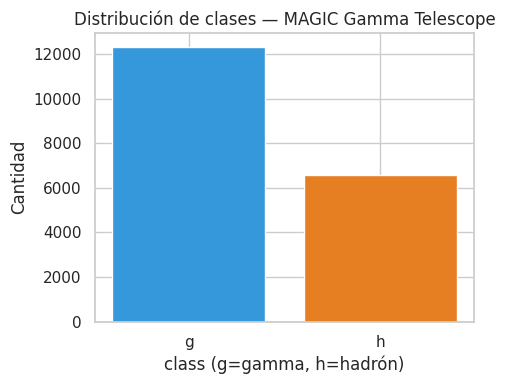

In [ ]:
# 9.2.2  Etapa 2 — Exploración y preparación de datos
print('Valores nulos por columna:')
print(df_ex2.isnull().sum())
print(f"\nRegistros duplicados: {df_ex2.duplicated().sum()}")
df_ex2 = df_ex2.drop_duplicates().reset_index(drop=True)

print(df_ex2.describe())

# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 4))
target_counts_ex2 = df_ex2['class'].value_counts()
ax.bar(target_counts_ex2.index, target_counts_ex2.values, color=['#3498db', '#e67e22'])
ax.set_title('Distribución de clases — MAGIC Gamma Telescope')
ax.set_xlabel('class (g=gamma, h=hadrón)')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

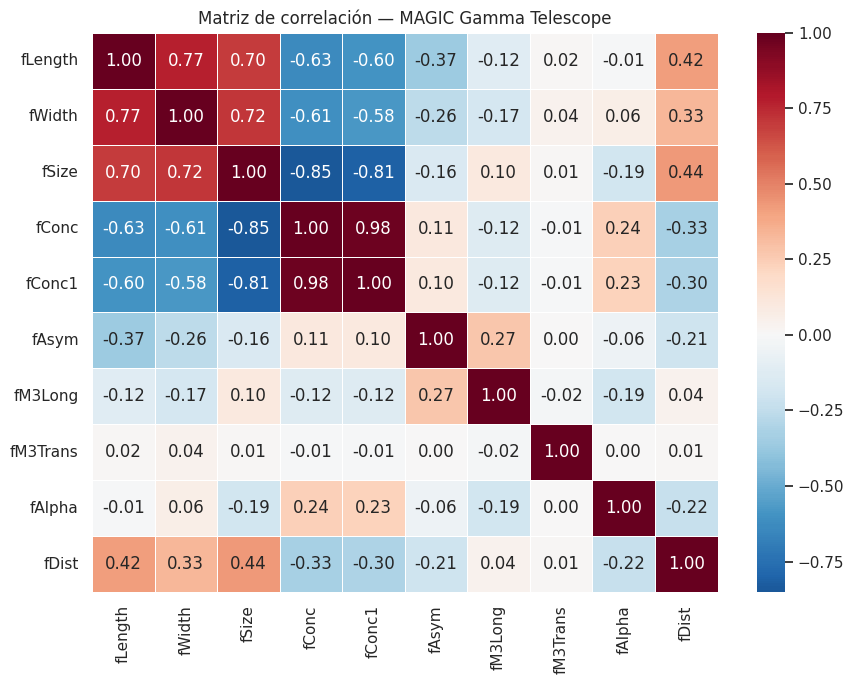

In [ ]:
# 9.2.3  Matriz de correlación entre las variables numéricas
plt.figure(figsize=(9, 7))
corr_ex2 = df_ex2.drop(columns='class').corr()
sns.heatmap(corr_ex2, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Matriz de correlación — MAGIC Gamma Telescope')
plt.tight_layout()
plt.show()

In [ ]:
# 9.2.4 Etapa 3 – Preparación para el modelado
from sklearn.preprocessing import LabelEncoder  # <--- Importación agregada

# Codificamos la clase: g (gamma) -> 0, h (hadrón) -> 1
le_ex2 = LabelEncoder()
df_ex2['class'] = le_ex2.fit_transform(df_ex2['class'])
print('Codificación:', dict(zip(le_ex2.classes_, le_ex2.transform(le_ex2.classes_))))

X_ex2 = df_ex2.drop(columns='class')
y_ex2 = df_ex2['class']

X_train_ex2, X_test_ex2, y_train_ex2, y_test_ex2 = train_test_split(
    X_ex2, y_ex2, test_size=0.20, random_state=42, stratify=y_ex2
)

print(f'Train: {X_train_ex2.shape[0]} muestras | Test: {X_test_ex2.shape[0]} muestras')

Codificación: {'g': np.int64(0), 'h': np.int64(1)}
Train: 15124 muestras | Test: 3781 muestras


In [ ]:
# 9.2.5  Etapa 4 — Entrenamiento de modelos (mismo esquema de pipelines que en la sección 5)
pipelines_ex2 = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

results_ex2 = {}
for name, pipe in pipelines_ex2.items():
    scores = cross_val_score(pipe, X_train_ex2, y_train_ex2, cv=5, scoring='accuracy')
    results_ex2[name] = scores
    print(f'{name:20s} -> Accuracy CV: {scores.mean():.4f} (+/- {scores.std():.4f})')

LogisticRegression   -> Accuracy CV: 0.7919 (+/- 0.0070)
DecisionTree         -> Accuracy CV: 0.8293 (+/- 0.0037)
RandomForest         -> Accuracy CV: 0.8532 (+/- 0.0043)


Mejor modelo: RandomForest
Accuracy en test: 0.8577

              precision    recall  f1-score   support

           g       0.84      0.96      0.90      2466
           h       0.90      0.66      0.76      1315

    accuracy                           0.86      3781
   macro avg       0.87      0.81      0.83      3781
weighted avg       0.86      0.86      0.85      3781



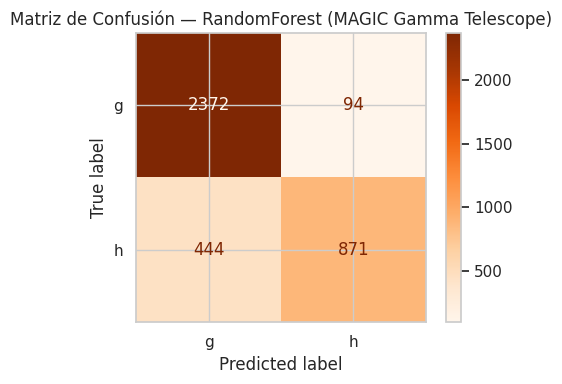

In [ ]:
# 9.2.6  Etapa 5 — Evaluación del mejor modelo
best_name_ex2 = max(results_ex2, key=lambda k: results_ex2[k].mean())
best_pipeline_ex2 = pipelines_ex2[best_name_ex2]
best_pipeline_ex2.fit(X_train_ex2, y_train_ex2)

y_pred_ex2 = best_pipeline_ex2.predict(X_test_ex2)

print(f'Mejor modelo: {best_name_ex2}')
print(f'Accuracy en test: {best_pipeline_ex2.score(X_test_ex2, y_test_ex2):.4f}\n')
print(classification_report(y_test_ex2, y_pred_ex2, target_names=list(le_ex2.classes_)))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_ex2, y_pred_ex2, display_labels=list(le_ex2.classes_), cmap='Oranges', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name_ex2} (MAGIC Gamma Telescope)')
plt.tight_layout()
plt.show()

In [ ]:
# 9.2.7  Etapa 6 — Serialización del modelo
MODEL_PATH_EX2 = 'magic_gamma_model.joblib'
joblib.dump(best_pipeline_ex2, MODEL_PATH_EX2)
print(f'Modelo guardado en: {MODEL_PATH_EX2}')

Modelo guardado en: magic_gamma_model.joblib


---
### ✅ Resolución — Ejercicio 3: Registro de experimentos con MLflow

**MLflow** es una librería de código abierto para llevar un registro (*tracking*) de experimentos de Machine Learning: guarda automáticamente los hiperparámetros usados, las métricas obtenidas y el modelo entrenado en cada ejecución (*run*), permitiendo comparar experimentos de forma ordenada.

**Pasos realizados:**
1. Instalación de la librería `mlflow`.
2. Creación de un experimento llamado `ciclo_vida_ml_sesion01`.
3. Registro de un *run* por cada modelo entrenado en la Sección 5 (Heart Disease): parámetros del modelo y accuracy promedio de validación cruzada.
4. Registro adicional del modelo `RandomForest` optimizado en el Ejercicio 1 (con sus mejores hiperparámetros y su accuracy en test).
5. Consulta de los experimentos registrados con `mlflow.search_runs()`.

In [ ]:
# 9.3.1  Instalación de MLflow (solo la primera vez)
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 9.3.2  Configuración del experimento
import mlflow

mlflow.set_experiment('ciclo_vida_ml_sesion01')
print('Experimento configurado.')

2026/09/18 03:11:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/18 03:11:41 INFO mlflow.store.db.utils: Updating database tables
2026/09/18 03:11:48 INFO mlflow.tracking.fluent: Experiment with name 'ciclo_vida_ml_sesion01' does not exist. Creating a new experiment.


Experimento configurado.


In [ ]:
# 9.3.3  Registro de los 3 modelos base entrenados en la Sección 5 (Heart Disease)
for name, scores in results.items():
    with mlflow.start_run(run_name=f'heart_disease_{name}'):
        pipeline = pipelines[name]
        mlflow.log_param('dataset', 'heart_disease')
        mlflow.log_param('modelo', name)

        # Log de hiperparámetros específicos según el modelo
        clf = pipeline.named_steps['clf']
        for param_name, param_value in clf.get_params().items():
            if param_name in ('n_estimators', 'max_depth', 'max_iter',
                               'min_samples_split', 'min_samples_leaf'):
                mlflow.log_param(param_name, param_value)

        mlflow.log_metric('cv_accuracy_mean', float(scores.mean()))
        mlflow.log_metric('cv_accuracy_std', float(scores.std()))

print('Modelos de la Sección 5 registrados en MLflow.')

Modelos de la Sección 5 registrados en MLflow.


In [ ]:
# 9.3.4  Registro del modelo RandomForest optimizado (Ejercicio 1)
with mlflow.start_run(run_name='heart_disease_RandomForest_tuned'):
    mlflow.log_param('dataset', 'heart_disease')
    mlflow.log_param('modelo', 'RandomForest_tuned')
    for param_name, param_value in rf_search.best_params_.items():
        mlflow.log_param(param_name, param_value)
    mlflow.log_metric('cv_accuracy_mean', float(rf_search.best_score_))
    mlflow.log_metric('test_accuracy', float(acc_rf_after))

print('Modelo optimizado registrado en MLflow.')

Modelo optimizado registrado en MLflow.


In [ ]:
# 9.3.5  Registro de los modelos entrenados en el Ejercicio 2 (Breast Cancer)
for name, scores in results_ex2.items():
    with mlflow.start_run(run_name=f'magic_gamma_{name}'):
        pipeline = pipelines_ex2[name]
        mlflow.log_param('dataset', 'magic_gamma_telescope')
        mlflow.log_param('modelo', name)

        clf = pipeline.named_steps['clf']
        for param_name, param_value in clf.get_params().items():
            if param_name in ('n_estimators', 'max_depth', 'max_iter',
                               'min_samples_split', 'min_samples_leaf'):
                mlflow.log_param(param_name, param_value)

        mlflow.log_metric('cv_accuracy_mean', float(scores.mean()))
        mlflow.log_metric('cv_accuracy_std', float(scores.std()))

print('Modelos del Ejercicio 2 registrados en MLflow.')

Modelos del Ejercicio 2 registrados en MLflow.


In [ ]:
# 9.3.6  Consulta de todos los experimentos registrados
runs_df = mlflow.search_runs()
cols_to_show = [c for c in runs_df.columns if c.startswith('params.modelo')
                or c.startswith('params.dataset')
                or c.startswith('metrics.cv_accuracy_mean')
                or c.startswith('metrics.test_accuracy')]
runs_df[cols_to_show].sort_values('metrics.cv_accuracy_mean', ascending=False)

,metrics.cv_accuracy_mean,metrics.test_accuracy,params.dataset,params.modelo
0,0.853214,NaN,magic_gamma_telescope,RandomForest
3,0.842600,0.851852,heart_disease,RandomForest_tuned
1,0.829344,NaN,magic_gamma_telescope,DecisionTree
6,0.828753,NaN,heart_disease,LogisticRegression
4,0.814799,NaN,heart_disease,RandomForest
2,0.791854,NaN,magic_gamma_telescope,LogisticRegression
5,0.763742,NaN,heart_disease,DecisionTree


---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*